In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [4]:
data = pd.read_csv('../data/raw_dataset/train.csv')
data = data.drop(columns=['Id'])

**Let's explore our dataset**

In [5]:
data.shape #shape of the dataset, we have 1460 rows and 81 columns in the dataset.

(1460, 80)

In [6]:
data.head() #displaying the first 5 rows of the dataset.

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
data.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [8]:
data["PoolQC"].value_counts()

PoolQC
Gd    3
Ex    2
Fa    2
Name: count, dtype: int64

In [9]:
data["MSZoning"].value_counts().sort_values()

MSZoning
C (all)      10
RH           16
FV           65
RM          218
RL         1151
Name: count, dtype: int64

In [10]:
data["LotFrontage"].value_counts()

LotFrontage
60.0     143
70.0      70
80.0      69
50.0      57
75.0      53
        ... 
138.0      1
160.0      1
152.0      1
153.0      1
46.0       1
Name: count, Length: 110, dtype: int64

In [11]:
data[data.columns[3]].value_counts()

LotArea
7200     25
9600     24
6000     17
10800    14
9000     14
         ..
26142     1
9262      1
17217     1
13175     1
9717      1
Name: count, Length: 1073, dtype: int64

In [12]:
data[data.columns[4]].value_counts()

Street
Pave    1454
Grvl       6
Name: count, dtype: int64

In [13]:
data[data.columns[5]].value_counts()

Alley
Grvl    50
Pave    41
Name: count, dtype: int64

In [14]:
data[data.columns[6]].value_counts()

LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

In [15]:
data[data.columns[7]].value_counts()

LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

In [16]:
data[data.columns[8]].value_counts()

Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

In [17]:
data.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [18]:
data[data.columns[9]].value_counts()

LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

In [19]:
data['LandSlope'].value_counts()

LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

In [20]:
data['RoofMatl'].value_counts()

RoofMatl
CompShg    1434
Tar&Grv      11
WdShngl       6
WdShake       5
Metal         1
Membran       1
Roll          1
ClyTile       1
Name: count, dtype: int64

In [21]:
data["1stFlrSF"].value_counts()

1stFlrSF
864     25
1040    16
912     14
848     12
894     12
        ..
1423     1
913      1
1578     1
2073     1
1256     1
Name: count, Length: 753, dtype: int64

**Let's check correlations**

In [22]:
residual = data["1stFlrSF"] + data["2ndFlrSF"] + data["LowQualFinSF"]
data["GrLivArea"].corr(residual)

np.float64(1.0)

In [23]:
residual.head()

0    1710
1    1262
2    1786
3    1717
4    2198
dtype: int64

In [24]:
data["GrLivArea"].head()

0    1710
1    1262
2    1786
3    1717
4    2198
Name: GrLivArea, dtype: int64

In [25]:
data[["1stFlrSF", "2ndFlrSF", "LowQualFinSF", "GrLivArea"]].head()

,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea
0,856,854,0,1710
1,1262,0,0,1262
2,920,866,0,1786
3,961,756,0,1717
4,1145,1053,0,2198


In [26]:
data["LowQualFinSF"].value_counts()

LowQualFinSF
0      1434
80        3
360       2
513       1
234       1
528       1
572       1
144       1
392       1
371       1
390       1
420       1
473       1
156       1
515       1
53        1
232       1
481       1
120       1
514       1
397       1
479       1
205       1
384       1
Name: count, dtype: int64

<Axes: title={'center': 'GrLivArea Distribution'}, ylabel='Density'>

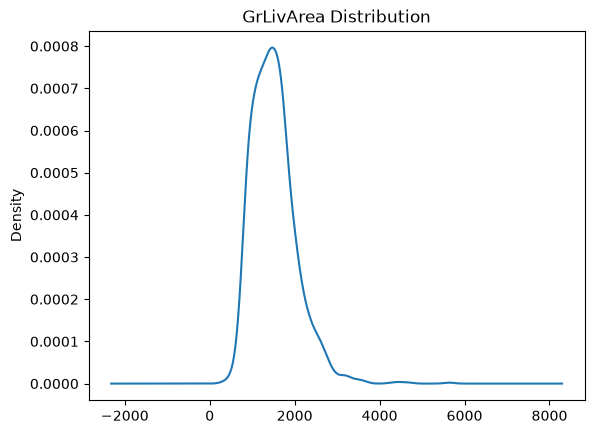

In [27]:
data["GrLivArea"].plot(kind='kde', title='GrLivArea Distribution')

In [28]:
test_1 = data[["1stFlrSF", "2ndFlrSF", "LowQualFinSF", "GrLivArea"]].corr()

In [29]:
test_1

,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea
1stFlrSF,1.000000,-0.202646,-0.014241,0.566024
2ndFlrSF,-0.202646,1.000000,0.063353,0.687501
LowQualFinSF,-0.014241,0.063353,1.000000,0.134683
GrLivArea,0.566024,0.687501,0.134683,1.000000


<Axes: >

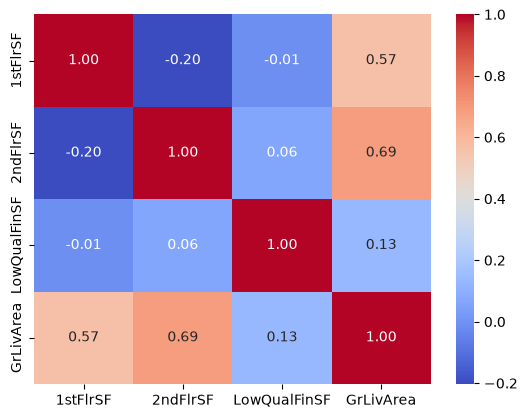

In [30]:
sns.heatmap(test_1, annot=True, cmap='coolwarm', fmt=".2f")

In [31]:
basement_testing = ["BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF"]

In [32]:
basement_corr = data[basement_testing].corr()

In [33]:
basement_corr

,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF
BsmtFinSF1,1.000000,-0.050117,-0.495251,0.522396
BsmtFinSF2,-0.050117,1.000000,-0.209294,0.104810
BsmtUnfSF,-0.495251,-0.209294,1.000000,0.415360
TotalBsmtSF,0.522396,0.104810,0.415360,1.000000


<Axes: title={'center': 'Basement Area Distribution'}, ylabel='Density'>

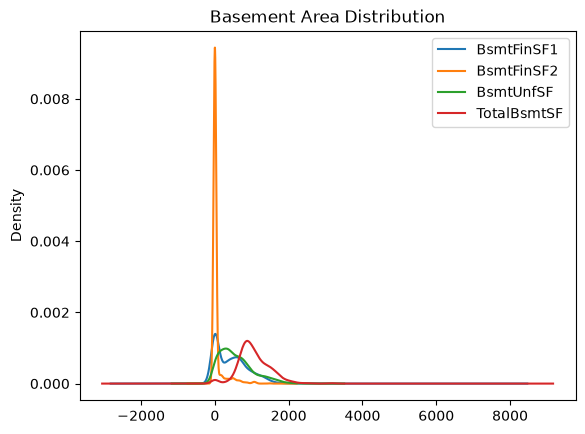

In [34]:
data[basement_testing].plot(kind='kde', title='Basement Area Distribution')

In [49]:
to_be_dropped = ["1stFlrSF", "2ndFlrSF", "LowQualFinSF",
                "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "GarageCars"]

In [ ]:
from assignments.helpers import preprocess_data
preprocessed_data = preprocess_data()

In [38]:
preprocessed_data.shape

(1460, 75)

In [39]:
check = data["GrLivArea"] - (data["1stFlrSF"] + data["2ndFlrSF"] + data["LowQualFinSF"])
check.describe()

count    1460.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
dtype: float64

<Axes: title={'center': 'Garage Area Distribution'}>

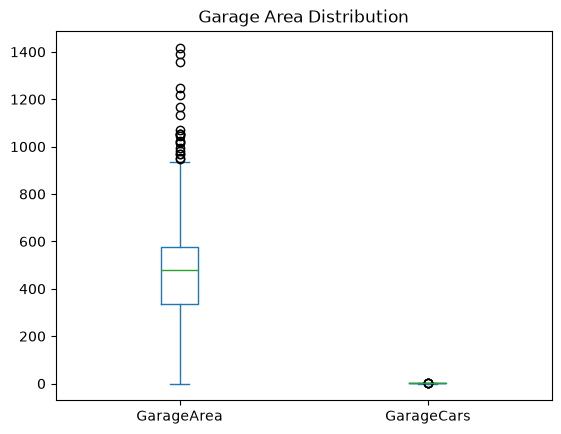

In [46]:
data[["GarageArea", "GarageCars"]].plot(kind='box', title='Garage Area Distribution')
# data["GarageCars"].plot(kind='kde', title='Garage Cars Distribution')

<Axes: title={'center': 'Garage Area vs Garage Cars'}, xlabel='GarageArea', ylabel='GarageCars'>

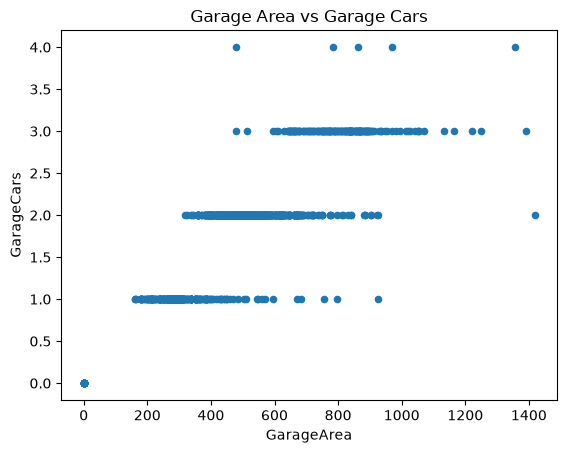

In [44]:
data[["GarageArea", "GarageCars"]].plot(kind='scatter', x='GarageArea', y='GarageCars', title='Garage Area vs Garage Cars')

In [45]:
data[["GarageArea", "GarageCars"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   GarageArea  1460 non-null   int64
 1   GarageCars  1460 non-null   int64
dtypes: int64(2)
memory usage: 22.9 KB


In [47]:
data["GarageCars"].corr(data["GarageArea"])

np.float64(0.8824754142814627)

<Axes: xlabel='GarageCars', ylabel='GarageArea'>

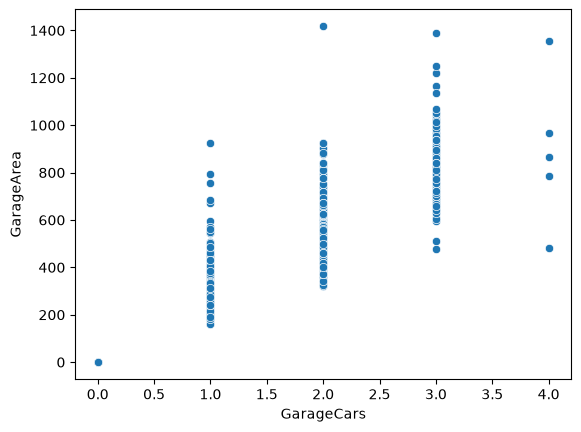

In [48]:
sns.scatterplot(x=data["GarageCars"], y=data["GarageArea"])

In [51]:
to_be_dropped = ["1stFlrSF", "2ndFlrSF", "LowQualFinSF",
                "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "GarageArea",
                ]

In [52]:
to_be_dropped

['1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'GarageArea']

In [59]:
print(data["YearBuilt"].corr(data["YearRemodAdd"]))
print(data["YearBuilt"].corr(data["GarageYrBlt"]))

0.5928549763436504
0.825667484174342


<Axes: xlabel='YearBuilt', ylabel='YearRemodAdd'>

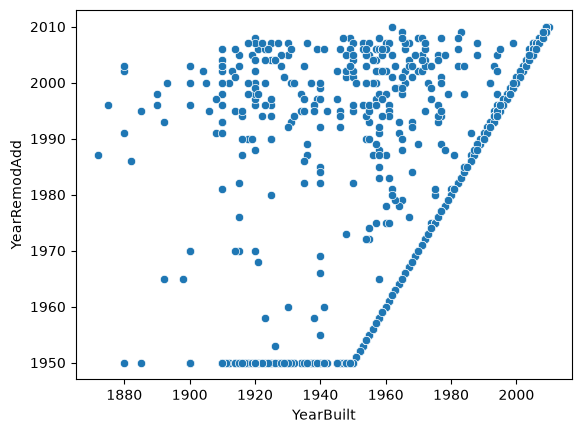

In [56]:
sns.scatterplot(x=data["YearBuilt"], y=data["YearRemodAdd"])

<Axes: xlabel='YearBuilt', ylabel='GarageYrBlt'>

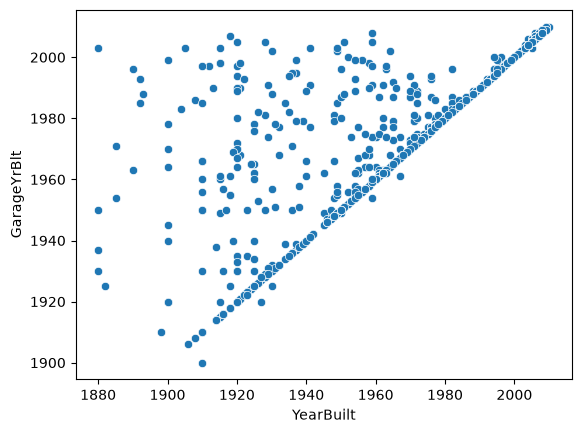

In [57]:
sns.scatterplot(x=data["YearBuilt"], y=data["GarageYrBlt"])

In [60]:
to_be_dropped += ["GarageYrBlt", "YearRemodAdd"]

In [ ]:
to_be_reconsidered = ["YearRemodAdd"]

In [61]:
to_be_dropped

['1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'GarageArea',
 'GarageYrBlt',
 'YearRemodAdd']

In [62]:
data["LotArea"].corr(data["LotFrontage"])

np.float64(0.42609501877180805)

<Axes: xlabel='LotFrontage', ylabel='LotArea'>

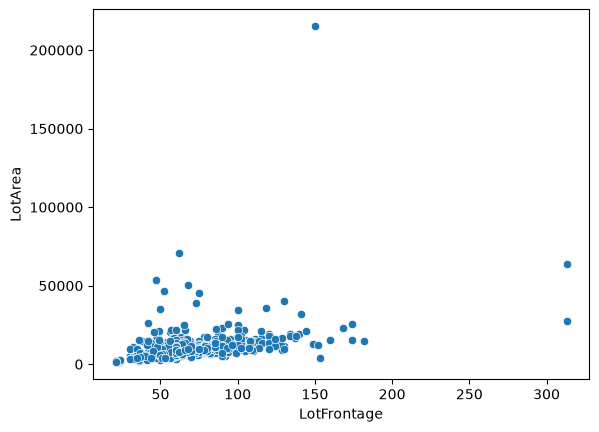

In [63]:
sns.scatterplot(x=data["LotFrontage"], y=data["LotArea"])

<Axes: title={'center': 'Lot Frontage Distribution'}, ylabel='Density'>

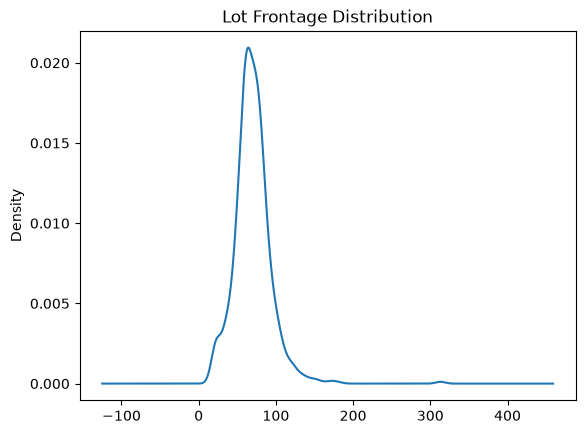

In [65]:
data["LotFrontage"].plot(kind='kde', title='Lot Frontage Distribution')

In [72]:
data[["LotFrontage", "LotArea"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LotFrontage  1201 non-null   float64
 1   LotArea      1460 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 22.9 KB


In [73]:
to_be_dropped += ["LotFrontage"]

In [74]:
to_be_dropped

['1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'GarageArea',
 'GarageYrBlt',
 'YearRemodAdd',
 'LotFrontage']

In [75]:
to_be_reconsidered += ["LotFrontage"]

In [76]:
to_be_reconsidered

['YearRemodAdd', 'LotFrontage']

In [77]:
quality_map = {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}

data["ExterQual_num"] = data["ExterQual"].map(quality_map)
data["KitchenQual_num"] = data["KitchenQual"].map(quality_map)
data["BsmtQual_num"] = data["BsmtQual"].map(quality_map)

In [79]:
print(data["OverallQual"].corr(data["ExterQual_num"]))
print(data["KitchenQual_num"].corr(data["ExterQual_num"]))
print(data["OverallQual"].corr(data["BsmtQual_num"]))

0.7262784907641424
0.7161221955033016
0.6646495818720216


In [80]:
data["OverallQual"].corr(data["KitchenQual_num"])

np.float64(0.6733307811877876)

In [81]:
to_be_dropped += ["ExterQual", "BsmtQual", "KitchenQual"]

In [83]:
len(to_be_dropped)

13

In [84]:
to_be_dropped

['1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'GarageArea',
 'GarageYrBlt',
 'YearRemodAdd',
 'LotFrontage',
 'ExterQual',
 'BsmtQual',
 'KitchenQual']

**Checking Near constants**

In [85]:
data["Utilities"].value_counts()

Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

In [ ]:
to_be_dropped += ["Utilities"]

In [95]:
data["Heating"].value_counts()

Heating
GasA     1428
GasW       18
Grav        7
Wall        4
OthW        2
Floor       1
Name: count, dtype: int64

In [96]:
to_be_dropped += ["Street","Condition2","RoofMatl","PoolArea", "PoolQC","3SsnPorch", "LandSlope","Alley",
                  "Heating"]

In [ ]:
weak_numerical = [
    "BsmtFullBath", "BsmtHalfBath", "HalfBath", "BedroomAbvGr",
    "KitchenAbvGr", "TotRmsAbvGrd", "WoodDeckSF", "OpenPorchSF",
    "EnclosedPorch", "ScreenPorch", "MiscVal", "MoSold", "YrSold"
]

data[weak_numerical + ["SalePrice"]].corr()["SalePrice"].sort_values()

KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
YrSold          -0.028923
MiscVal         -0.021190
BsmtHalfBath    -0.016844
MoSold           0.046432
ScreenPorch      0.111447
BedroomAbvGr     0.168213
BsmtFullBath     0.227122
HalfBath         0.284108
OpenPorchSF      0.315856
WoodDeckSF       0.324413
TotRmsAbvGrd     0.533723
SalePrice        1.000000
Name: SalePrice, dtype: float64

<Axes: >

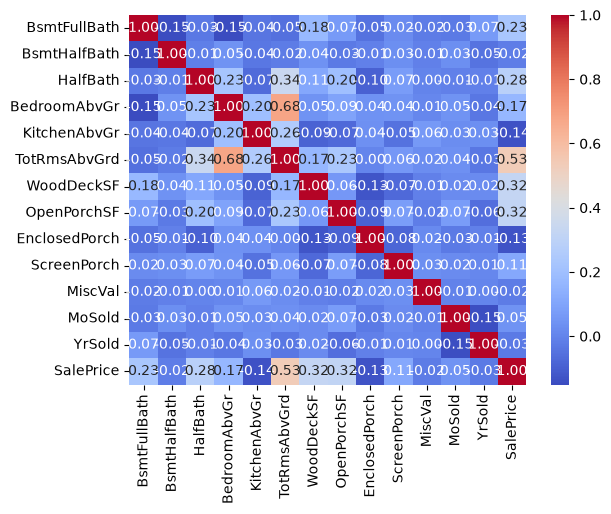

In [104]:
sns.heatmap(data[weak_numerical + ["SalePrice"]].corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [107]:
data["TotRmsAbvGrd"].corr(data["GrLivArea"])

np.float64(0.8254893743088428)

In [110]:
weak_categorical = [
    "MSSubClass", "MSZoning", "LotShape", "LandContour", "Condition1",
    "RoofStyle", "Exterior1st", "Exterior2nd", "MasVnrType", "Foundation",
    "BsmtCond", "BsmtFinType1", "BsmtFinType2", "Electrical", "Functional",
    "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "PavedDrive", "Fence", "MiscFeature", "SaleType", "SaleCondition", "HeatingQC"
]

for col in weak_categorical:
    print(col)
    print(data.groupby(col)["SalePrice"].mean().sort_values())
    print()

MSSubClass
MSSubClass
30      95829.724638
180    102300.000000
45     108591.666667
190    129613.333333
90     133541.076923
160    138647.380952
50     143302.972222
85     147810.000000
40     156125.000000
70     166772.416667
80     169736.551724
20     185224.811567
75     192437.500000
120    200779.080460
60     239948.501672
Name: SalePrice, dtype: float64

MSZoning
MSZoning
C (all)     74528.000000
RM         126316.830275
RH         131558.375000
RL         191004.994787
FV         214014.061538
Name: SalePrice, dtype: float64

LotShape
LotShape
Reg    164754.818378
IR1    206101.665289
IR3    216036.500000
IR2    239833.365854
Name: SalePrice, dtype: float64

LandContour
LandContour
Bnk    143104.079365
Lvl    180183.746758
Low    203661.111111
HLS    231533.940000
Name: SalePrice, dtype: float64

Condition1
Condition1
Artery    135091.666667
RRAe      138400.000000
Feedr     142475.481481
RRAn      184396.615385
Norm      184495.492063
RRNe      190750.000000
RRNn      21

In [113]:
data["LandContour"].value_counts()

LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

In [ ]:
to_be_dropped = ['1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'BsmtFinSF1', 'BsmtFinSF2','BsmtUnfSF','GarageArea',
 'GarageYrBlt', 'YearRemodAdd', 'LotFrontage', 'ExterQual', 'BsmtQual', 'KitchenQual', 'Utilities', 'Street',
 'Condition2', 'RoofMatl', 'PoolArea', 'PoolQC', '3SsnPorch', 'LandSlope', 'Alley', 'Heating',"BsmtFullBath", 
 "BsmtHalfBath", "HalfBath", "BedroomAbvGr", "KitchenAbvGr", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch", 
 "ScreenPorch", "MiscVal", "MoSold", "YrSold", "TotRmsAbvGrd","MSSubClass", "MSZoning", "LandContour",
 "Foundation", "PavedDrive", "SaleType", "HouseStyle","LotShape"]

In [134]:
len(to_be_dropped)

43

In [114]:
data.groupby("Foundation")["SalePrice"].size()
data["YearBuilt"].corr(pd.get_dummies(data["Foundation"])["PConc"])

np.float64(0.6511992774741352)

In [116]:
quality_map = {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
data["FireplaceQu_num"] = data["FireplaceQu"].map(quality_map)

print(data["FireplaceQu_num"].corr(data["Fireplaces"]))
print(data["FireplaceQu_num"].corr(data["OverallQual"]))

0.028839532850375982
0.3558665473715009


In [118]:
quality_map2 = {"Unf": 1, "RFn": 2, "Fin": 3}
data["GarageFinish_num"] = data["GarageFinish"].map(quality_map2)

print(data["GarageFinish_num"].corr(data["GarageCars"]))
print(data["GarageFinish_num"].corr(data["OverallQual"]))

0.4312214753527018
0.5196232161279264


In [120]:
data["GarageFinish"].value_counts()

GarageFinish
Unf    605
RFn    422
Fin    352
Name: count, dtype: int64

In [122]:
data["PavedDrive"].value_counts()

PavedDrive
Y    1340
N      90
P      30
Name: count, dtype: int64

In [123]:
data.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [125]:
data["SaleType"].value_counts()

SaleType
WD       1267
New       122
COD        43
ConLD       9
ConLI       5
ConLw       5
CWD         4
Oth         3
Con         2
Name: count, dtype: int64

In [126]:
pd.crosstab(data["SaleType"], data["SaleCondition"])

SaleCondition,Abnorml,AdjLand,Alloca,Family,Normal,Partial
SaleType,,,,,,
COD,24,0,0,0,19,0
CWD,1,0,0,1,2,0
Con,0,0,0,0,2,0
ConLD,2,0,0,0,6,1
ConLI,1,0,0,0,4,0
ConLw,0,0,0,0,5,0
New,0,0,0,0,0,122
Oth,3,0,0,0,0,0
WD,70,4,12,19,1160,2


In [129]:
quality_map3 = {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
data["HeatingQC_num"] = data["HeatingQC"].map(quality_map3)

data["HeatingQC_num"].corr(data["OverallQual"])

np.float64(0.45708254828660977)

In [130]:
data.groupby("HouseStyle")["SalePrice"].mean().sort_values()

HouseStyle
1.5Unf    110150.000000
SFoyer    135074.486486
1.5Fin    143116.740260
2.5Unf    157354.545455
SLvl      166703.384615
1Story    175985.477961
2Story    210051.764045
2.5Fin    220000.000000
Name: SalePrice, dtype: float64

In [131]:
data.groupby("HouseStyle")["GrLivArea"].mean().sort_values()

HouseStyle
1.5Unf     896.428571
SFoyer     973.378378
1Story    1308.599174
SLvl      1373.861538
1.5Fin    1564.948052
2Story    1887.411236
2.5Unf    1907.636364
2.5Fin    2848.000000
Name: GrLivArea, dtype: float64

In [132]:
data.groupby("Neighborhood")["SalePrice"].mean().sort_values()

Neighborhood
MeadowV     98576.470588
IDOTRR     100123.783784
BrDale     104493.750000
BrkSide    124834.051724
Edwards    128219.700000
OldTown    128225.300885
Sawyer     136793.135135
Blueste    137500.000000
SWISU      142591.360000
NPkVill    142694.444444
NAmes      145847.080000
Mitchel    156270.122449
SawyerW    186555.796610
NWAmes     189050.068493
Gilbert    192854.506329
Blmngtn    194870.882353
CollgCr    197965.773333
Crawfor    210624.725490
ClearCr    212565.428571
Somerst    225379.837209
Veenker    238772.727273
Timber     242247.447368
StoneBr    310499.000000
NridgHt    316270.623377
NoRidge    335295.317073
Name: SalePrice, dtype: float64

In [135]:
data.groupby("LotShape")["SalePrice"].size()

LotShape
IR1    484
IR2     41
IR3     10
Reg    925
Name: SalePrice, dtype: int64

In [136]:
data.groupby("LotShape")["LotArea"].mean()

LotShape
IR1    11894.545455
IR2    23733.658537
IR3    41338.200000
Reg     8876.915676
Name: LotArea, dtype: float64

In [137]:
data.groupby("Condition1")["SalePrice"].size()

Condition1
Artery      48
Feedr       81
Norm      1260
PosA         8
PosN        19
RRAe        11
RRAn        26
RRNe         2
RRNn         5
Name: SalePrice, dtype: int64

In [138]:
data.groupby("RoofStyle")["SalePrice"].size()

RoofStyle
Flat         13
Gable      1141
Gambrel      11
Hip         286
Mansard       7
Shed          2
Name: SalePrice, dtype: int64

In [139]:
print(data.groupby("Exterior1st")["SalePrice"].size())
print(data.groupby("Exterior2nd")["SalePrice"].size())

Exterior1st
AsbShng     20
AsphShn      1
BrkComm      2
BrkFace     50
CBlock       1
CemntBd     61
HdBoard    222
ImStucc      1
MetalSd    220
Plywood    108
Stone        2
Stucco      25
VinylSd    515
Wd Sdng    206
WdShing     26
Name: SalePrice, dtype: int64
Exterior2nd
AsbShng     20
AsphShn      3
Brk Cmn      7
BrkFace     25
CBlock       1
CmentBd     60
HdBoard    207
ImStucc     10
MetalSd    214
Other        1
Plywood    142
Stone        5
Stucco      26
VinylSd    504
Wd Sdng    197
Wd Shng     38
Name: SalePrice, dtype: int64


In [140]:
data["YearBuilt"].corr(pd.get_dummies(data["Exterior1st"])["VinylSd"])

np.float64(0.5187342065943391)

In [141]:
data.groupby("MasVnrType")["SalePrice"].size()

MasVnrType
BrkCmn      15
BrkFace    445
Stone      128
Name: SalePrice, dtype: int64

In [142]:
data.groupby("BsmtCond")["SalePrice"].size()

BsmtCond
Fa      45
Gd      65
Po       2
TA    1311
Name: SalePrice, dtype: int64

In [143]:
print(data.groupby("BsmtFinType1")["SalePrice"].size())
print(data.groupby("BsmtFinType2")["SalePrice"].size())

BsmtFinType1
ALQ    220
BLQ    148
GLQ    418
LwQ     74
Rec    133
Unf    430
Name: SalePrice, dtype: int64
BsmtFinType2
ALQ      19
BLQ      33
GLQ      14
LwQ      46
Rec      54
Unf    1256
Name: SalePrice, dtype: int64


In [144]:
data["TotalBsmtSF"].corr(pd.get_dummies(data["BsmtFinType1"])["GLQ"])

np.float64(0.31739606633836415)

In [145]:
data.groupby("Electrical")["SalePrice"].size()

Electrical
FuseA      94
FuseF      27
FuseP       3
Mix         1
SBrkr    1334
Name: SalePrice, dtype: int64

In [146]:
data.groupby("Functional")["SalePrice"].size()

Functional
Maj1      14
Maj2       5
Min1      31
Min2      34
Mod       15
Sev        1
Typ     1360
Name: SalePrice, dtype: int64

In [147]:
data.groupby("GarageType")["SalePrice"].size()

GarageType
2Types       6
Attchd     870
Basment     19
BuiltIn     88
CarPort      9
Detchd     387
Name: SalePrice, dtype: int64

In [148]:
print(data["GarageCars"].corr(pd.get_dummies(data["GarageType"])["Attchd"]))
print(data["GarageFinish_num"].corr(pd.get_dummies(data["GarageType"])["Attchd"]))

0.32061487066265304
0.38578981033777454


In [149]:
data.groupby("Fence")["SalePrice"].size()

Fence
GdPrv     59
GdWo      54
MnPrv    157
MnWw      11
Name: SalePrice, dtype: int64

In [150]:
data.groupby("MiscFeature")["SalePrice"].size()

MiscFeature
Gar2     2
Othr     2
Shed    49
TenC     1
Name: SalePrice, dtype: int64

In [151]:
print(data["OverallCond"].corr(data["SalePrice"]))
print(data.groupby("OverallCond")["SalePrice"].size())

-0.077855894048678
OverallCond
1      1
2      5
3     25
4     57
5    821
6    252
7    205
8     72
9     22
Name: SalePrice, dtype: int64


In [152]:
quality_map4 = {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
data["ExterCond_num"] = data["ExterCond"].map(quality_map4)

data["ExterCond_num"].corr(data["SalePrice"])
data.groupby("ExterCond")["SalePrice"].size()

ExterCond
Ex       3
Fa      28
Gd     146
Po       1
TA    1282
Name: SalePrice, dtype: int64

In [153]:
data["ExterCond_num"].corr(data["SalePrice"])

np.float64(0.018899118482413036)

In [154]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import pandas as pd

# Quick check, using only numerical predictors for now (categorical need encoding first)
numerical_cols = ["LotArea", "OverallQual", "YearBuilt", "MasVnrArea", 
                   "TotalBsmtSF", "GrLivArea", "FullBath", "Fireplaces", "GarageCars"]

X = data[numerical_cols].fillna(0)  # quick fill, just for this check
y = data["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Train R²:", r2_score(y_train, model.predict(X_train)))
print("Test R²:", r2_score(y_test, model.predict(X_test)))

Train R²: 0.7704976742344148
Test R²: 0.8049913320054098


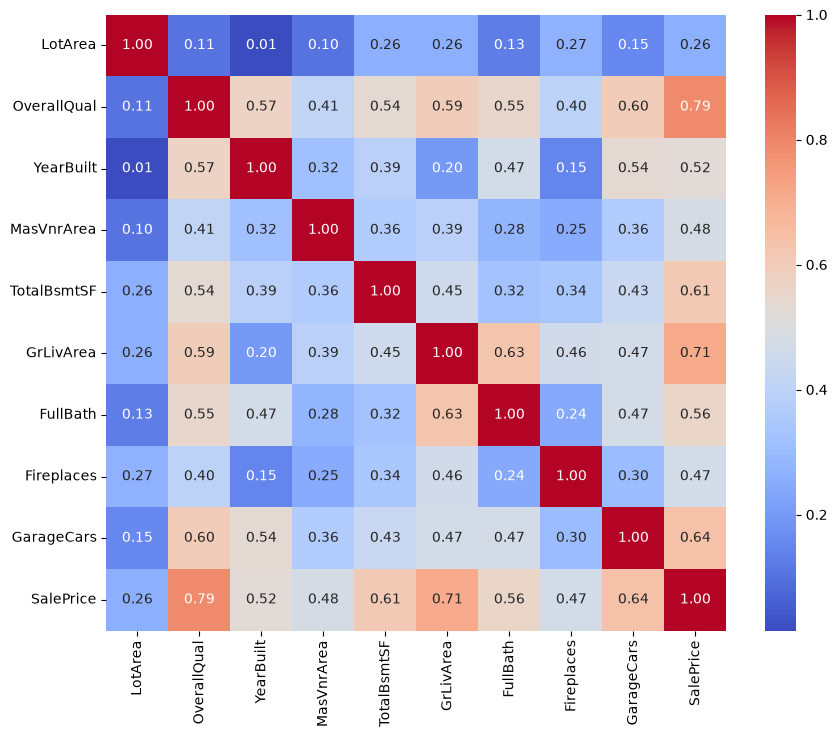

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = ["LotArea", "OverallQual", "YearBuilt", "MasVnrArea", 
                   "TotalBsmtSF", "GrLivArea", "FullBath", "Fireplaces", "GarageCars", "SalePrice"]

plt.figure(figsize=(10, 8))
sns.heatmap(data[numerical_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()